# 🏠 Anomaly Detection — Suite du travail
## Chargement du modèle sauvegardé + Injection d'anomalies
### ☁️ Google Colab

> ✅ **Pas besoin de réentraîner** — on charge directement `lstm_ae.pt` depuis Drive

---
### Résultats déjà obtenus :
| Maison | Jours analysés | Jours anormaux | % |
|---|---|---|---|
| House 1 | 552 | 103 | 18.7% |
| House 2 | 458 | 37  | 8.1%  |
| House 3 | 536 | 35  | 6.5%  |
| House 4 | 533 | 0   | 0.0%  |
| House 5 | 576 | 13  | 2.3%  |

## 0. Mount Drive + Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import random
import warnings
warnings.filterwarnings('ignore')

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Device : {DEVICE}')

Mounted at /content/drive
Device : cuda


## 1. Recharger le modèle sauvegardé

In [2]:
# ── Redefinir l'architecture (obligatoire pour charger les poids) ──────────────
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return h_n[-1]

class LSTMDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, seq_len, num_layers, dropout):
        super().__init__()
        self.seq_len = seq_len
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        z_seq  = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.lstm(z_seq)
        return self.fc(out)

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, seq_len, num_layers, dropout):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size, num_layers, dropout)
        self.decoder = LSTMDecoder(hidden_size, input_size, seq_len, num_layers, dropout)
    def forward(self, x):
        return self.decoder(self.encoder(x))


# ── Charger le checkpoint ──────────────────────────────────────────────────────
MODEL_PATH = '/content/drive/MyDrive/REFIT_dataset clean/outputs/lstm_ae.pt'
ckpt       = torch.load(MODEL_PATH, map_location=DEVICE)
CFG        = ckpt['config']
threshold  = ckpt['threshold']

# Reconstruire le scaler
scaler          = MinMaxScaler()
scaler.scale_   = np.array(ckpt['scaler_scale_'])
scaler.min_     = np.array(ckpt['scaler_min_'])
scaler.data_min_   = (0 - scaler.min_) / scaler.scale_
scaler.data_max_   = (1 - scaler.min_) / scaler.scale_
scaler.data_range_ = scaler.data_max_ - scaler.data_min_
scaler.n_features_in_ = len(scaler.scale_)

# Reconstruire le modele
model = LSTMAutoencoder(
    input_size  = 1,
    hidden_size = CFG['hidden_size'],
    seq_len     = CFG['minutes_per_day'],
    num_layers  = CFG['num_layers'],
    dropout     = CFG['dropout'],
).to(DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'Modele charge depuis : {MODEL_PATH}')
print(f'Seuil restaure       : {threshold:.5f}')
print('Pret a utiliser ✅')

Modele charge depuis : /content/drive/MyDrive/REFIT_dataset clean/outputs/lstm_ae.pt
Seuil restaure       : 0.02176
Pret a utiliser ✅


## 2. Recharger les données de la maison de test

In [3]:
def load_house(path, cfg):
    df = pd.read_csv(path, usecols=[cfg['time_col'], cfg['aggregate_col']])
    df[cfg['time_col']] = pd.to_datetime(df[cfg['time_col']])
    df = df.set_index(cfg['time_col']).sort_index()
    minute_series = df[cfg['aggregate_col']].resample('1min').mean()
    X_days, dates, skipped = [], [], 0
    for date, grp in minute_series.groupby(minute_series.index.date):
        if grp.notna().sum() < cfg['min_day_coverage']:
            skipped += 1; continue
        full_idx = pd.date_range(start=f'{date} 00:00',
                                  periods=cfg['minutes_per_day'], freq='1min')
        day = grp.reindex(full_idx).ffill(limit=cfg['max_gap_fill_minutes']).fillna(0)
        X_days.append(day.values.astype(np.float32))
        dates.append(str(date))
    return np.array(X_days, dtype=np.float32), dates


# Charger uniquement la maison de test
test_path     = CFG['house_paths'][CFG['test_house_idx']]
X_test_raw, test_dates = load_house(test_path, CFG)
X_test_sc     = scaler.transform(X_test_raw)

print(f'Maison TEST     : House {CFG["test_house_idx"]+1}')
print(f'Jours charges   : {len(test_dates)}')

# Recalculer les erreurs de reconstruction
def get_errors(X_sc, batch_size=64):
    model.eval()
    errors = []
    with torch.no_grad():
        for s in range(0, len(X_sc), batch_size):
            xb  = torch.tensor(X_sc[s:s+batch_size]).unsqueeze(-1).to(DEVICE)
            err = ((xb - model(xb)) ** 2).mean(dim=(1, 2)).cpu().numpy()
            errors.extend(err)
    return np.array(errors)

test_errors = get_errors(X_test_sc)
y_pred      = (test_errors > threshold).astype(int)
print(f'Jours anormaux  : {y_pred.sum()} ({y_pred.mean()*100:.1f}%)')
print(f'Seuil           : {threshold:.5f}')

Maison TEST     : House 5
Jours charges   : 576
Jours anormaux  : 13 (2.3%)
Seuil           : 0.02176


## 3. Injection d'anomalies artificielles

On prend le **jour le plus normal** de la maison de test et on y injecte des valeurs aberrantes de 3 façons différentes pour valider que le modèle les détecte.

In [4]:
ANOMALY_VALUE = 9999   # valeur aberrante injectee


def score_day(day_sc):
    """Score MSE d'un jour deja normalise."""
    model.eval()
    with torch.no_grad():
        x   = torch.tensor(day_sc, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(DEVICE)
        rec = model(x).squeeze().cpu().numpy()
        mse = float(((day_sc - rec) ** 2).mean())
    return mse, rec


def inject_and_score(day_sc, inject_fn):
    """Injecte l'anomalie dans l'espace reel puis rescale et score."""
    day_real      = scaler.inverse_transform(day_sc.reshape(1, -1)).flatten()
    day_corrupted = inject_fn(day_real.copy())
    day_corrupt_sc = scaler.transform(day_corrupted.reshape(1, -1)).flatten()
    mse, rec       = score_day(day_corrupt_sc)
    return mse, day_corrupt_sc, rec


# Choisir le jour le plus normal comme reference
best_idx  = int(np.argmin(test_errors))
best_day  = X_test_sc[best_idx]
best_date = test_dates[best_idx]
mse_orig, recon_orig = score_day(best_day)

print(f'Jour de reference : {best_date}')
print(f'MSE original      : {mse_orig:.5f}  → {"NORMAL ✅" if mse_orig < threshold else "ANORMAL 🚨"}')
print(f'Seuil             : {threshold:.5f}')
print()

# ── CAS 1 : 60 minutes aleatoires ─────────────────────────────────────────────
random_minutes = random.sample(range(1440), 60)
def inject_random(day):
    day[random_minutes] = ANOMALY_VALUE
    return day
mse1, corrupt1, recon1 = inject_and_score(best_day, inject_random)
print(f'CAS 1 — 60 min aleatoires  | MSE={mse1:.5f} | {"🚨 DETECTE" if mse1 > threshold else "❌ Non detecte"}')

# ── CAS 2 : Plage horaire 8h-10h ──────────────────────────────────────────────
def inject_range(day):
    day[480:600] = ANOMALY_VALUE   # 8h00 -> 10h00
    return day
mse2, corrupt2, recon2 = inject_and_score(best_day, inject_range)
print(f'CAS 2 — Plage 8h-10h       | MSE={mse2:.5f} | {"🚨 DETECTE" if mse2 > threshold else "❌ Non detecte"}')

# ── CAS 3 : Toute la journee ───────────────────────────────────────────────────
def inject_all(day):
    day[:] = ANOMALY_VALUE
    return day
mse3, corrupt3, recon3 = inject_and_score(best_day, inject_all)
print(f'CAS 3 — Journee entiere    | MSE={mse3:.5f} | {"🚨 DETECTE" if mse3 > threshold else "❌ Non detecte"}')

Jour de reference : 2014-08-09
MSE original      : 0.00047  → NORMAL ✅
Seuil             : 0.02176

CAS 1 — 60 min aleatoires  | MSE=0.08157 | 🚨 DETECTE
CAS 2 — Plage 8h-10h       | MSE=0.03342 | 🚨 DETECTE
CAS 3 — Journee entiere    | MSE=1.60803 | 🚨 DETECTE


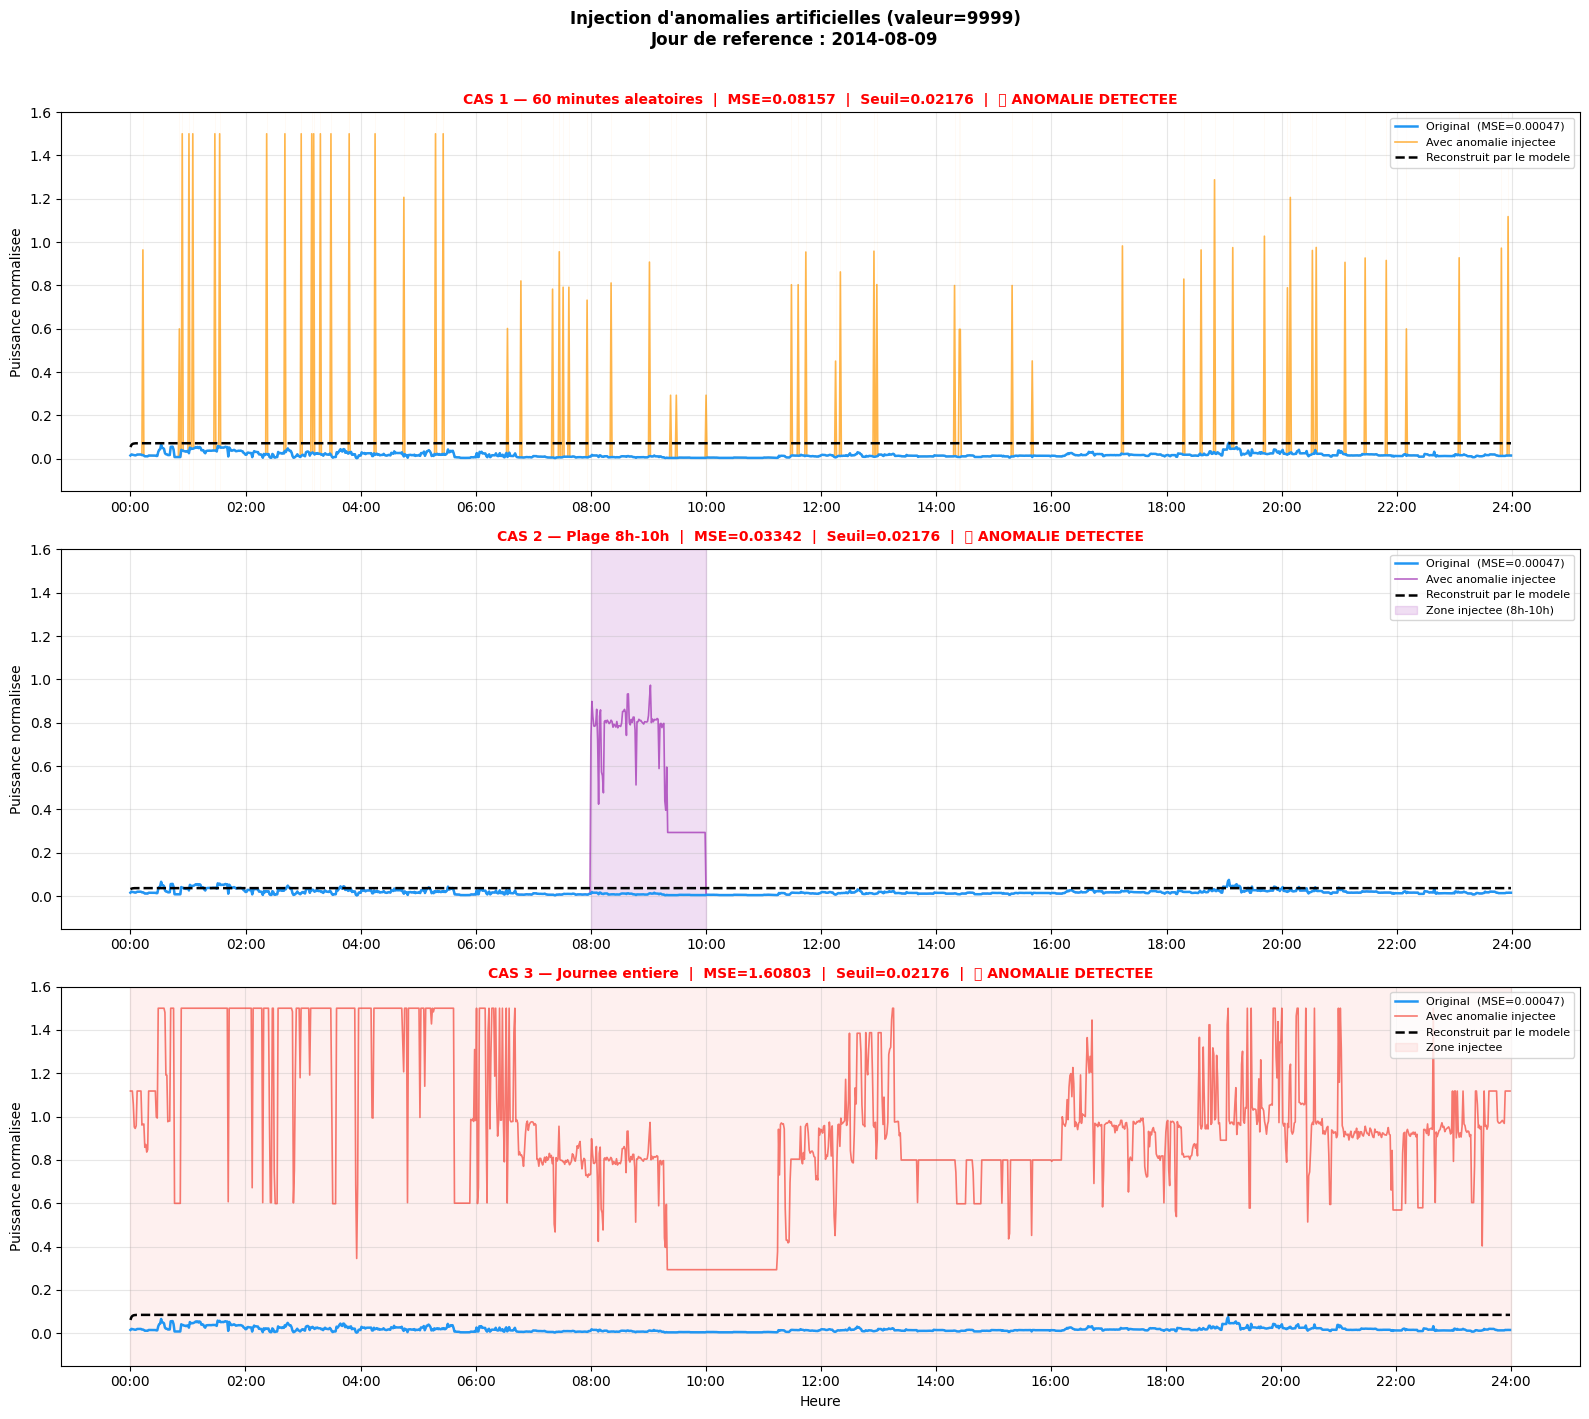


=== Recap ===
Scenario                              MSE      Seuil         Detecte
--------------------------------------------------------------------
Original (sans injection)         0.00047    0.02176           NON ❌
CAS 1 - Minutes aleatoires        0.08157    0.02176           OUI 🚨
CAS 2 - Plage 8h-10h              0.03342    0.02176           OUI 🚨
CAS 3 - Journee entiere           1.60803    0.02176           OUI 🚨


In [5]:
# ── Visualisation des 3 cas ────────────────────────────────────────────────────
h = np.arange(1440) / 60

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

cas = [
    (corrupt1, recon1, mse1, 'CAS 1 — 60 minutes aleatoires', '#FF9800'),
    (corrupt2, recon2, mse2, 'CAS 2 — Plage 8h-10h',          '#9C27B0'),
    (corrupt3, recon3, mse3, 'CAS 3 — Journee entiere',        '#F44336'),
]

for ax, (corrupt, recon, mse, title, color) in zip(axes, cas):
    detected = mse > threshold

    # Original
    ax.plot(h, best_day, color='#2196F3', linewidth=1.8,
            label=f'Original  (MSE={mse_orig:.5f})', zorder=3)

    # Corrompu (clip pour lisibilite)
    ax.plot(h, np.clip(corrupt, -0.1, 1.5), color=color, linewidth=1.2,
            alpha=0.7, label='Avec anomalie injectee', zorder=2)

    # Reconstruction
    ax.plot(h, recon, color='black', linewidth=1.8, linestyle='--',
            label='Reconstruit par le modele', zorder=4)

    # Zone injectee
    if 'aleatoires' in title:
        for m in random_minutes:
            ax.axvline(m/60, color=color, alpha=0.06, linewidth=0.5)
    elif '8h' in title:
        ax.axvspan(8, 10, color=color, alpha=0.15, label='Zone injectee (8h-10h)')
    else:
        ax.axvspan(0, 24, color=color, alpha=0.08, label='Zone injectee')

    # Titre avec resultat
    status = '🚨 ANOMALIE DETECTEE' if detected else '❌ Non detecte'
    ax.set_title(
        f"{title}  |  MSE={mse:.5f}  |  Seuil={threshold:.5f}  |  {status}",
        fontsize=10, fontweight='bold',
        color='red' if detected else 'gray'
    )
    ax.set_ylabel('Puissance normalisee')
    ax.set_xticks(range(0, 25, 2))
    ax.set_xticklabels([f'{hh:02d}:00' for hh in range(0, 25, 2)])
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.15, 1.6)

axes[-1].set_xlabel('Heure')
plt.suptitle(
    f'Injection d\'anomalies artificielles (valeur={ANOMALY_VALUE})\n'
    f'Jour de reference : {best_date}',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/REFIT_dataset clean/outputs/11_anomaly_injection.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Tableau recapitulatif
print('\n=== Recap ===')
print(f'{"Scenario":<30} {"MSE":>10} {"Seuil":>10} {"Detecte":>15}')
print('-' * 68)
for label, mse_v in [
    ('Original (sans injection)', mse_orig),
    ('CAS 1 - Minutes aleatoires', mse1),
    ('CAS 2 - Plage 8h-10h',       mse2),
    ('CAS 3 - Journee entiere',     mse3),
]:
    det = 'OUI 🚨' if mse_v > threshold else 'NON ❌'
    print(f'{label:<30} {mse_v:>10.5f} {threshold:>10.5f} {det:>15}')

---
## Ce que montrent ces résultats

| Cas | Anomalie injectée | Ce que ça simule |
|---|---|---|
| **CAS 1** | 60 minutes aléatoires | Pic électrique soudain imprévisible |
| **CAS 2** | 8h → 10h | Personne n'a pas fait sa routine matinale |
| **CAS 3** | Toute la journée | Journée complètement hors norme |

Le modèle détecte l'anomalie quand **l'erreur de reconstruction MSE dépasse le seuil**.
La reconstruction reste proche du pattern normal appris — incapable de suivre les valeurs aberrantes.